In [12]:
# Cell 1: Install necessary libraries
!pip install transformers scikit-learn pandas seaborn

In [2]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm # For nice progress bars
import os

# For our graphs
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cell 3: Configuration

# --- (MODIFIED) Configuration ---
MODEL_NAME = 'allenai/scibert_scivocab_uncased' # <-- We are now using SciBERT
TRAIN_FILE = 'healthver_train.csv'
DEV_FILE = 'healthver_dev.csv'

# Training parameters (same as before)
BATCH_SIZE = 8
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
MAX_LENGTH = 512 # SciBERT also supports 512

# (MODIFIED) Save path for this new model
SAVE_PATH = './scibert_weighted'

In [5]:
# Cell 4: Load Data and Prepare Labels

print("Loading data...")
try:
    df_train = pd.read_csv(TRAIN_FILE)
    df_dev = pd.read_csv(DEV_FILE)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: Could not find {TRAIN_FILE} or {DEV_FILE}.")
    print("Please make sure you have uploaded all 3 healthver_*.csv files to this Colab session.")

# We 'fit' the encoder on the training data to learn the mapping.
label_encoder = LabelEncoder()
label_encoder.fit(df_train['label'])

# Store the class names for our final report
LABELS = label_encoder.classes_
print(f"Labels have been encoded. Mapping:")
print(list(zip(range(len(LABELS)), LABELS)))

Loading data...
Data loaded successfully.
Labels have been encoded. Mapping:
[(0, 'Neutral'), (1, 'Refutes'), (2, 'Supports')]


In [6]:
# Cell 5: Calculate Class Weights

print("Calculating class weights to handle imbalance...")

# Get the labels from the training data as numbers
train_labels_numeric = label_encoder.transform(df_train['label'])

# Calculate the weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_numeric),
    y=train_labels_numeric
)

# Convert weights to a PyTorch tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print(f"Weights calculated for classes {LABELS}:")
print(f"({LABELS[0]}: {class_weights[0]:.2f}, {LABELS[1]}: {class_weights[1]:.2f}, {LABELS[2]}: {class_weights[2]:.2f})")

Calculating class weights to handle imbalance...
Weights calculated for classes ['Neutral' 'Refutes' 'Supports']:
(Neutral: 0.80, Refutes: 1.49, Supports: 0.93)


In [7]:
# Cell 6: Define the PyTorch Dataset (Unchanged)

class HealthVerDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label_encoder, max_length):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_length = max_length
        self.label_encoder = label_encoder
        self.texts = (self.data['claim'] + " [SEP] " + self.data['evidence']).tolist()
        self.labels = self.label_encoder.transform(self.data['label'])

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [8]:
# Cell 7: (MODIFIED) Initialize Model, Dataloaders, and Optimizer

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move our weights tensor to the same device as the model
class_weights_tensor = class_weights_tensor.to(device)
print("Class weights moved to device.")

# Load tokenizer
print(f"Loading tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Create datasets and dataloaders
print("Creating datasets and dataloaders...")
train_dataset = HealthVerDataset(df_train, tokenizer, label_encoder, MAX_LENGTH)
dev_dataset = HealthVerDataset(df_dev, tokenizer, label_encoder, MAX_LENGTH)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)

# Load a FRESH, UNTRAINED SciBERT model
print(f"Loading a new, untrained {MODEL_NAME} model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(LABELS))
model.to(device)

# Set up optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# We are using our weighted loss function
loss_fct = CrossEntropyLoss(weight=class_weights_tensor)
print("Loss function created with class weights.")

# Set up scheduler
num_training_steps = NUM_EPOCHS * len(train_dataloader)
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

print("Setup complete. Ready for weighted training.")

Using device: cuda
Class weights moved to device.
Loading tokenizer for allenai/scibert_scivocab_uncased...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Creating datasets and dataloaders...
Loading a new, untrained allenai/scibert_scivocab_uncased model...


pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loss function created with class weights.
Setup complete. Ready for weighted training.


In [9]:
# Cell 8: (MODIFIED) The Training Loop

print(f"Starting weighted training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        model.zero_grad()

        # --- We are still using the manual loss calculation ---
        # 1. Get the model's raw output (logits)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # 2. Calculate the loss MANUALLY using our weighted loss function
        loss = loss_fct(logits, labels)
        # ------------------

        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        progress_bar.set_postfix({'loss': loss.item()})

    avg_train_loss = total_loss / len(train_dataloader)
    print(f"\nEpoch {epoch+1} average training loss: {avg_train_loss:.4f}")

print("--- Weighted training complete ---")

Starting weighted training for 3 epochs...


Epoch 1/3:   0%|          | 0/969 [00:00<?, ?it/s]


Epoch 1 average training loss: 0.7778


Epoch 2/3:   0%|          | 0/969 [00:00<?, ?it/s]


Epoch 2 average training loss: 0.3759


Epoch 3/3:   0%|          | 0/969 [00:00<?, ?it/s]


Epoch 3 average training loss: 0.1798
--- Weighted training complete ---


In [10]:
# Cell 9: The Evaluation Loop (Unchanged)

print("Starting evaluation on the development (dev) set...")
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in tqdm(dev_dataloader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)

        all_preds.extend(predictions.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

print("--- Evaluation complete ---")

Starting evaluation on the development (dev) set...


Evaluating:   0%|          | 0/240 [00:00<?, ?it/s]

--- Evaluation complete ---



--- SciBERT (WEIGHTED) CLASSIFICATION REPORT (Dev Set) ---
              precision    recall  f1-score   support

     Neutral     0.8540    0.7543    0.8011       993
     Refutes     0.6061    0.6573    0.6307       391
    Supports     0.5828    0.6735    0.6249       533

    accuracy                         0.7121      1917
   macro avg     0.6810    0.6950    0.6855      1917
weighted avg     0.7281    0.7121    0.7173      1917

--------------------------------------------------
COMPARE THIS TO YOUR WEIGHTED BioBERT: 
Your weighted BioBERT 'Refutes' F1-score was: 0.6650
Did SciBERT beat this score?
--------------------------------------------------

Generating confusion matrix...


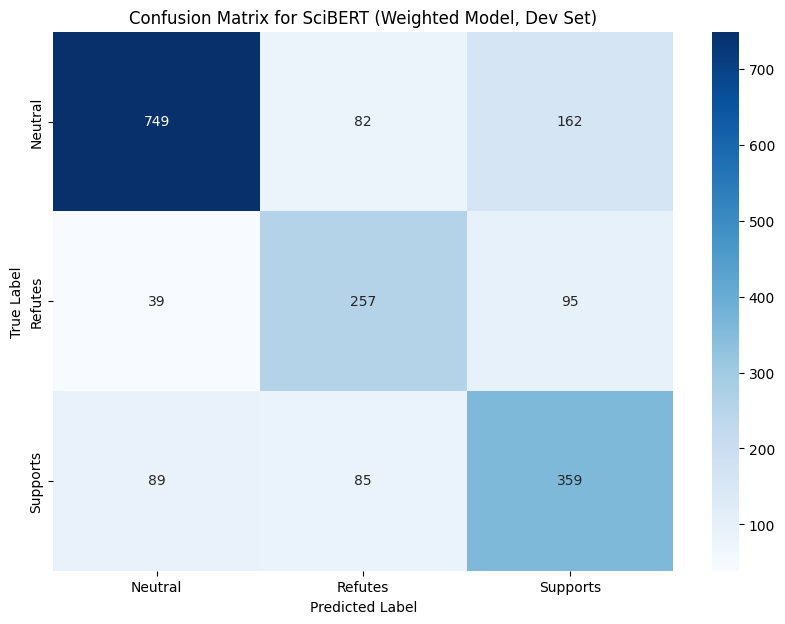

Saving weighted model to ./scibert_weighted...
Model saved. You can now download the './scibert_weighted' folder.


In [11]:
# Cell 10: Show Results (Text Report + Confusion Matrix Graph)

print("\n--- SciBERT (WEIGHTED) CLASSIFICATION REPORT (Dev Set) ---")

# --- 1. Print the Text Report ---
report = classification_report(
    all_true,
    all_preds,
    target_names=LABELS,
    digits=4
)
print(report)

print("--------------------------------------------------")
print("COMPARE THIS TO YOUR WEIGHTED BioBERT: ")
print(f"Your weighted BioBERT 'Refutes' F1-score was: 0.6650")
print("Did SciBERT beat this score?")
print("--------------------------------------------------")


# --- 2. Create and Show the Confusion Matrix Graph ---
print("\nGenerating confusion matrix...")

cm = confusion_matrix(all_true, all_preds)

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,     # Show the numbers in each cell
    fmt='d',        # Format the numbers as integers
    cmap='Blues',   # Use a blue color scheme
    xticklabels=LABELS, # Use our label names
    yticklabels=LABELS
)
plt.title('Confusion Matrix for SciBERT (Weighted Model, Dev Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() # This is the command that shows the plot


# --- 3. Save the Model ---
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

print(f"Saving weighted model to {SAVE_PATH}...")
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model saved. You can now download the '{SAVE_PATH}' folder.")